## 0) Model Selection 모듈
* 학습 데이터와 테스트 데이터셋을 분리 혹은 교차검증 분할 및 평가, Estimator의 하이퍼파라미터를 튜닝하기 위한 함수&클래스 제공

## 1) 학습/데이터셋 분리 - train_test_split()
* 전체 데이터를 학습/테스트 데이터셋으로 분리해줌
* sklearn.model_selection 모듈 > train_test_split()
  * 필수 파라미터 : 피처 데이터셋, 레이블 데이터셋
  * 선택 파라미터 : test_size(테스트 데이터셋 크기를 얼마로 샘플링 할 것인가?) train_size(학습 데이터셋 크기. 잘 사용 안함), shuffle(데이터 분리 전에 미리 섞을지. 디폴트는 True), random_state(호출 시마다 동일한 학습/데이터셋 생성하기 위해 주어지는 난수. 지정하지 않으면 수행시마다 다른 학습/테이터셋용 데이터 생성함)
  * 튜플 형태로 반환 : (학습 데이터의 피처 데이터셋, 테스트 데이터의 피처 데이터셋, 학습 데이터의 레이블 데이터셋, 테스트 데이터의 레입르 데이터셋)

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf = DecisionTreeClassifier()
iris_data = load_iris()

x_train, x_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.3, random_state=121)

dt_clf.fit(x_train, y_train) #학습데이터를 기반으로 DecisionTreeCLassifier을 학습하고, 이 모델로 예측 정확도 측정
pred = dt_clf.predict(x_test)
print('예측 정확도 : {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도 : 0.9556


## 2) 교차 검증
* 필요성
  * 과적합(Overfitting) : 모델이 학습 데이터에만 과도하게 최적화 되어, 실제 예측을 다른 데이터로 수행할 때 예측 성능이 과도하게 떨어지는 것
  * 고정된 학습데이터 & 테스트 데이터로 평가할 시 테스트 데이터에메나 최적의 성능을 발휘하도록 편항되게 모델을 유도하는 경우가 생김
  * 이를 방지하기 위해 교차검증을 이용해 다양한 학습&평가 시행
* 교차 검증
  * 테스트 데이터셋에 대해 평가하기 전, 많은 학습과 검증 세트에서 알고리즘 학습과 평가를 수행하는 것
  * 각 세트에서 수행한 평가 결과에 따라 하이퍼 파라미터 튜닝 등의 모델 최적화를 쉽게 할 수 있음
  * 대부분의 ML 모델의 성능 평가는 교차 검증을 기반으로 1차 평가 함 -> 최종적으로 테스트 데이터셋에 적용해 평가
  * ML에 사용되는 데이터셋 : 학습 + 검증 + 테스트 데이터셋
  * 학습 데이터 중 따로 할당을 해 별도의 검증 데이터셋을 두어 최종 평가 이전에 학습된 도멜을 다양하게 평가하는 데 사용함

### (1) K 폴드 교차 검증
* 가장 보편적으로 사용되는 교차 검증 기법
* K개의 데이터 폴드 세트를 만들어 K번 만큼 각 폴드 세트에 학습&검증 평가를 반복적으로 수행
  * 데이터셋을 K 등분함
  * 1번째 반복에서1 ~ (K-1)번째 등분을 학습 데이터셋으로, 마지막 K번째 등분 하나를 검증 데이터셋으로 설정한 뒤, 학습 데이터에 대해서는 학습을, 검증 데이터셋에서는 평가를 수행
  * 2번째 반복에서는 1 ~ (K-2)번째 등분과 K번째 등분을 학습 데이터셋으로, (K-1)번째 등분 하나를 검증 데이터셋으로 설정한 뒤, 같은 과정을 반복
  * 학습 데이터셋과 검증 데이터셋을 점진적으로 변경하며 마지막 K번째까지 학습과 검증을 수행
  * K개의 예측 평가를 구한 뒤, 이를 평균해 K 폴드 평가 결과로 반영
  * K=5인 경우의 K폴드 교차 검증
  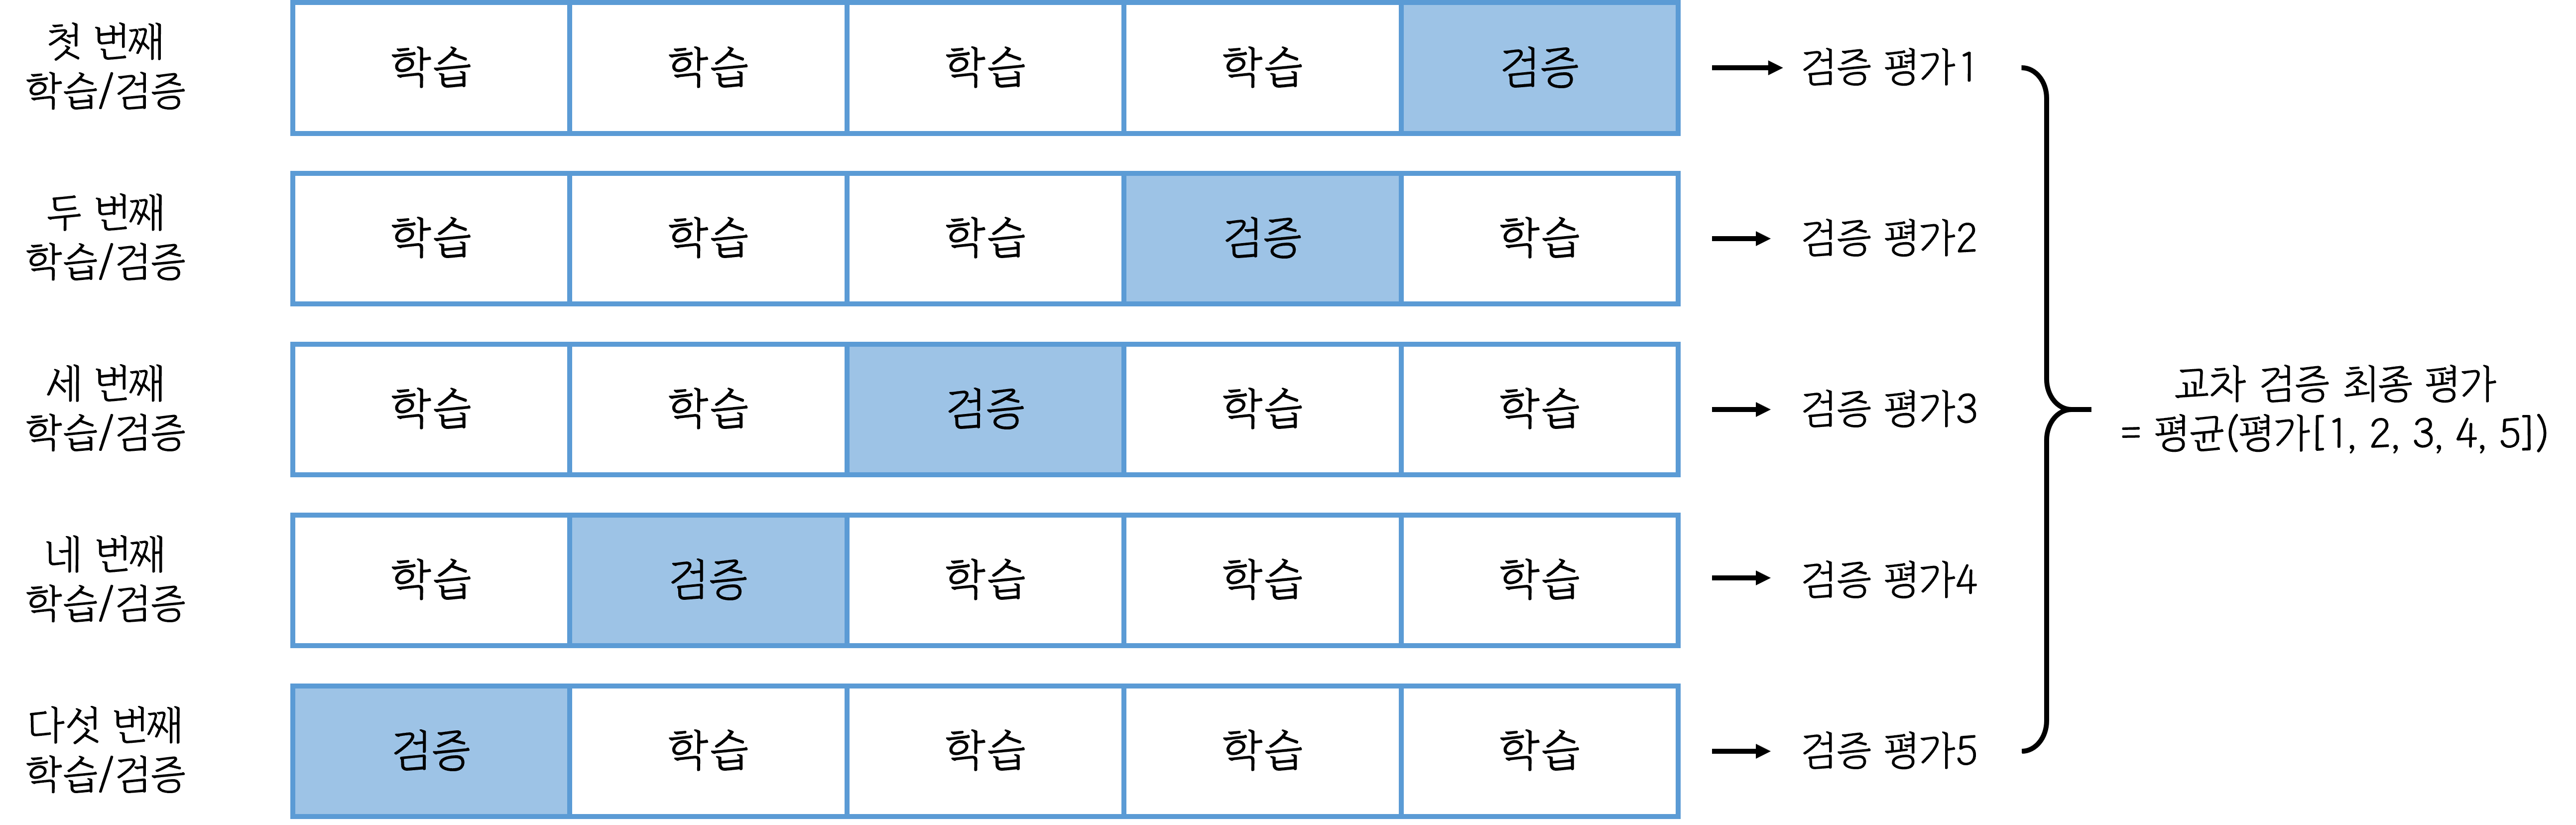
* 사이킷런에서는 K폴드 교차 검증 프로세스 구현을 위해 KFold와 StratifiedKFold 클래스 제공
  * KFold(n_splits=n)으로 KFold 객체 생성
  * KFold 객체의 split() 호출 시 전체 데이터를 n개의 폴드 데이터셋으로 분리
  * split() 호출 시 학습용/검증용 데이터로 분할할 수 있는 인덱스로 반환함
  * 학습용/검증용 데이터 추출은 반환된 인덱스를 기반으로 개발 코드에서 직접 수행해야 함

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state=156)

#5개의 폴드 세트로 분리하는 KFold 객체와 폴드 세트별 정확도를 담을 리스트 객체 생성
kfold = KFold(n_splits=5)
cv_accuracy = []
print('붖꽃 데이터 세트의 크기 : ', features.shape[0])

붖꽃 데이터 세트의 크기 :  150


In [27]:
### KFold 객체의 split()을 호출해 교차 검증 수행 시마다 학습과 검증을 반복해 예측 정확도 측정
### split()이 어떤 값을 실제로 반환하는지 확인하기 위해 검증 데이터 셋의 인덱스도 추출

n_iter = 0

#KFold 객체의 split()를 호출 시 폴드 별 학습용 & 검증용 테스트의 로우 인덱스를 array로 반환
for train_index, test_index in kfold.split(features):
    # kfold.split()으로 반환된 인덱스를 이용해 학습용, 검증용 데스트 데이터 추출
    x_train, x_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    # 학습 및 예측
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    n_iter += 1
    #반복 시마다 정확도 측정
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    print('#{0} 교차 검증 정확도 : {1}, 학습 데이터 크기 : {2}, 검증 데이터 크기 : {3}'.format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스 : {1}\n'.format(n_iter, test_index))
    cv_accuracy.append(accuracy)

# 개별 iterator 별 정확도를 합해 평균 정확도 계산
print('\n#평균 검증 정확도 : ', np.mean(cv_accuracy))

#1 교차 검증 정확도 : 1.0, 학습 데이터 크기 : 120, 검증 데이터 크기 : 30
#1 검증 세트 인덱스 : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도 : 0.9667, 학습 데이터 크기 : 120, 검증 데이터 크기 : 30
#2 검증 세트 인덱스 : [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도 : 0.8667, 학습 데이터 크기 : 120, 검증 데이터 크기 : 30
#3 검증 세트 인덱스 : [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도 : 0.9333, 학습 데이터 크기 : 120, 검증 데이터 크기 : 30
#4 검증 세트 인덱스 : [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도 : 0.7333, 학습 데이터 크기 : 120, 검증 데이터 크기 : 30
#5 검증 세트 인덱스 : [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]


#평균 검증 정확도 :  0.9


### (2) Stratified K 폴드
* 불균형한 분포도를 가진 레이블(결정 클래스) 데이터 집합을 위한 K폴드 방식
* 특정 레이블값이 특이하게 많거나 매우 적어 값의 분포가 한쪽으로 치우친 경우를 위함 -> 랜덤으로 테스트/학습 데이터셋 인덱스를 고를 경우, 불균형하게 배정될 가능성이 있음
* 원본 데이터 레이블 분포를 먼저 고려한 뒤 이 분포와 동일하게 학습과 검증 데이터 세트를 분배함
* KFold로 분할된 레이블 데이터셋이 전체 레이블 값의 분포도를 반영하지 못하는 문제 해결
* StraitifiedKFold는 KFold와 사용법이 유사하나, split() 메서드에 인자로 피처 데이터셋 뿐만 아니라 레이블 데이터셋도 반드시 필요
* 왜곡된 레이블 데이터셋에서 반드시 Straified K 폴드를 이용해 교차 검증해야 함
* 일반적으로 분류 문제에서 교차검증은 KFold가 아니라 Stratified K 폴드를 이용해 분할되어야 함
* 회귀 문제에서는 Stratified K 폴드 지원 안됨. 회귀는 결정값이 이산값 형태 레이블이 아닌 연속된 숫자 형태이므로 결정값변로 분포를 정할 의미 없기 때문

In [6]:
### StatisfiedKFold 학습 및 검증 레이블의 데이터값 분포도 확인
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target

skf = StratifiedKFold(n_splits=3)
n_iter = 0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test = iris_df['label'].iloc[test_index]
    print('#교차 검증 : {0}'.format(n_iter))
    print('학습 레이블 데이터 분포 : \n', label_train.value_counts())
    print('검증 레이블 데이터 분포 : \n', label_test.value_counts())

#교차 검증 : 1
학습 레이블 데이터 분포 : 
 2    34
1    33
0    33
Name: label, dtype: int64
검증 레이블 데이터 분포 : 
 1    17
0    17
2    16
Name: label, dtype: int64
#교차 검증 : 2
학습 레이블 데이터 분포 : 
 1    34
2    33
0    33
Name: label, dtype: int64
검증 레이블 데이터 분포 : 
 2    17
0    17
1    16
Name: label, dtype: int64
#교차 검증 : 3
학습 레이블 데이터 분포 : 
 0    34
2    33
1    33
Name: label, dtype: int64
검증 레이블 데이터 분포 : 
 2    17
1    17
0    16
Name: label, dtype: int64


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits=3)
n_iter = 0
cv_accuracy = []

for train_index, test_index in skfold.split(features, label): #StratifiedKFold의 split()호출 시 반드시 레이블 데이터셋도 추가 입력해야 함
    x_train, x_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    
    n_iter += 1
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = x_train.shape[0]
    test_size = x_test.shape[0]
    print('\n#{0} 교차 검증 정확도 : {1}, 학습 데이터 크기 : {2}, 검증 데이터 크기 : {3}'.format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스 : {1}'.format(n_iter, test_index))
    cv_accuracy.append(accuracy)
    
print('\n#교차 검증별 정확도 : ', np.round(cv_accuracy, 4))
print('#평균 검증 정확도 : ', np.mean(cv_accuracy))


#1 교차 검증 정확도 : 0.98, 학습 데이터 크기 : 100, 검증 데이터 크기 : 50
#1 검증 세트 인덱스 : [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도 : 0.94, 학습 데이터 크기 : 100, 검증 데이터 크기 : 50
#2 검증 세트 인덱스 : [ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도 : 0.98, 학습 데이터 크기 : 100, 검증 데이터 크기 : 50
#3 검증 세트 인덱스 : [ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

#교차 검증별 정확도 :  [0.98 0.94 0.98]
#평균 검증 정확도 :  0.9666666666666667


### (3) 교차 검증을 보다 간편하게 - cross_val_score()
* 기존 교차 검증 방법 : 폴드 세트를 설정 -> for 루프에서 반복으로 학습&테스트 데이터 인덱스 추출 -> 반복적으로 학습과 예측 수행하고 예측 성능 반환
* 사이킷런은 교차 검증을 위보다 편리하게 수행할 API 제공 -> cross_val_score()이 그 API
* 선언 형태 : cross_val_score(estimator, X, y=None, scoring=None, cv=None, n_jobs=1, verbose=0, fit_params=None, pre_dispatch='2*n_jogs')
  * estimator : 사이킷런의 분류 알고리즘 클래스 Classifier 또는 회귀 알고리즘 클래스 Regressor
  * X : 피처 데이터 세트
  * y : 레이블 데이터 세트
  * scoring : 예측 성능 평가 지표 기술
  * cv : 교차 검증 폴드 수
* scoring 파라미터로 지정된 성능 지표 측정값을 배열 형태로 반환
* classifier가 분류 클래스이면 Stratified K 폴드 방식으로, 회귀이면 K 폴드 방식으로 분할
* 즉, API 내부에서 Estimator을 학습(fit)-예측(predict)-평가(evaluation) 모두를 한번에 처리

* corss_validate() : 비슷한 API로, 여러 개의 평가 지표를 반환할 수 있음. 학습 데이터에 대한 성능 평가 지표와 수행 시간도 같이 제공

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
dt_clf = DecisionTreeClassifier(random_state = 156)

data = iris_data.data
label = iris_data.target

# 성능 지표 = 정확도(accuracy), 교차 검증 세트 3개
scores = cross_val_score(dt_clf, data, label, scoring='accuracy', cv=3)
print('교차 검증별 정확도 : ', np.round(scores, 4))
print('평균 검증별 정확도 : ', np.round(np.mean(scores), 4))

교차 검증별 정확도 :  [0.98 0.94 0.98]
평균 검증별 정확도 :  0.9667


## 3) GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한 번에
* Classifier/Regressor 같은 알고리즘에 사용되는 하이퍼 파라미터를 교차 검증을 기반으로 순차적으로 입력하며 편리하게 최적의 파라미터를 도출하도록 함(for문으로 일일히 할 필요 없이)
* 데이터 셋을 cross-validation을 위한 학습/테스트 세트로 자동 분할 -> 하이퍼 파라미터 그리드에 기술된 모든 파라미터를 순차적으로 적용 -> 최적의 파라미터 찾음
* 수행시간이 상대적으로 오래 걸림
* GridSearchCV의 클래스 생성자 파라미터
  * estimator : classifier, regressor, pipeline
  * param_grid : 키 & 리스트 값 갖는 딕셔너리. estimator의 튜닝을 위해 파라미터명 & 사용될 파라미터 값들 지정
  * scoring : 예측 성능을 측정할 평가 방법. 보통은 성능 평가 지표 지정할 문자열을 입력.(ex, 'accuracy') 혹은 별도 성능평가 지표 설정 가능
  * cv : 교차 검증을 위해 분할되는 학습/테스트 세트 개수
  * refit : 디폴트가 True. 가장 최적의 파라미터를 찾은 뒤 입력 estimator 객체를 해당 파라미터로 재학습 시킴
* GridSearchCV.fit()을 시키면 GridSearchCV.cv_result_에 반환값을 저장 -> pandas로 보기 쉽게 확인 가능
  * params : 수행할 때마다 적용된 개별 파라미터값
  * rank_test_score : 하이퍼 파라미터별로 성능이 좋은 score 순위. 1에 가까울 수록 높은 순위 & 최적 파라미터
  * mean_test_score : 개별 하이퍼 파라미터별로 CV의 폴딩 테스트 세트에 대해 총 수행한 평가 평균값
* best_params_, best_score_속성에 최고 성능을 내는 하이퍼 파라미터 값과 평가 결과값이 각각 저장
* best_estimator_ 속성에 refit으로 이미 학습된 estimator을 반환

In [3]:
### 결정트리 알고리즘의 여러 최적화 파라미터를 순차적으로 적용해 붓꽃 데이터 예측 분석하는 데 GridSearchCV 이용하기

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd

# 데이터 로딩 및 학습/테스트 데이터셋 분리
iris_data = load_iris()
x_train, x_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=121)

dtree = DecisionTreeClassifier()

#파라미터를 딕셔너리로 설정 - 의사결정트리 알고리즘의 주요 파라미터인 max_depth와 min_sample_split을 변화
#하이퍼 파라미터의 명칭은 key, 하이퍼 파라미터 값은 리스트 형으로 설정
parameters = {'max_depth':[1, 2, 3], 'min_samples_split':[2, 3]}

#parm_grid의 하이퍼 파라미너틀 3개의 학습/테스트 데이터셋 폴드로 나누어 테스트 수행 설정 : fit()
#수행 결과를 cv_results_속성에 기록함. 이를 Pandas의 DataFrame으로 변환하면 쉽게 볼 수 있음
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)
grid_dtree.fit(x_train, y_train)
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


In [5]:
print('GridSearchCV 최적 파라미터 : ', grid_dtree.best_params_)
print('GridSearchCV 최고 정확도 : {0:.4f}'.format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터 :  {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도 : 0.9750


In [6]:
from sklearn.metrics import accuracy_score

#GridSearchCV의 refit으로 이미 학습된 estimator 반환 -> 이미 최적 학습이 되었으므로 별도 학습 필요 없음
estimator = grid_dtree.best_estimator_
pred = estimator.predict(x_test)
print('테스트 데이터 세트 정확도 : {0:.4f}'.format(accuracy_score(y_test, pred)))

테스트 데이터 세트 정확도 : 0.9667
